In [26]:
# improt libraris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [9]:
plt.rcParams["axes.unicode_minus"] = False

In [2]:
data = pd.read_parquet("combined_employee_dataset.parquet", engine="pyarrow")
print("\ndtypes after saving and reloading from Parquet:")
print(data.dtypes)


dtypes after saving and reloading from Parquet:
employee_id                               object
department                                object
country                                   object
job_level                                 object
gender                                    object
age                                        int64
hire_date                         datetime64[ns]
tenure_days_as_of_2025_06_30               int64
annual_salary_usd                        float64
manager_id                                object
is_remote                                   bool
employment_status                         object
review_count                               int64
avg_performance_score                    float64
avg_manager_rating                       float64
avg_goal_completion_rate                 float64
trained_review_periods                     int64
last_review_date                  datetime64[ns]
total_enrollments                          int64
completed_count     

In [3]:
pd.set_option("display.max_columns", 120)
data.sample(5)

,employee_id,department,country,job_level,gender,age,hire_date,tenure_days_as_of_2025_06_30,annual_salary_usd,manager_id,is_remote,employment_status,review_count,avg_performance_score,avg_manager_rating,avg_goal_completion_rate,trained_review_periods,last_review_date,total_enrollments,completed_count,avg_assessment_score,avg_satisfaction,total_training_cost_usd,trained_in_compliance,trained_in_customer_experience,trained_in_leadership,trained_in_sales_enablement,trained_in_soft_skills,trained_in_technical,promotion_count,salary_increase_count,has_exited
771,EMP00772,Engineering,India,Individual Contributor,Female,30,2023-09-21,648,26200.0,EMP01785,True,Terminated,4,3.0075,3.00,62.225,1,2025-06-30,5,4,82.075000,3.450000,880.0,1,0,1,0,0,0,0,1,1
1438,EMP01439,Operations,India,Senior Manager,Female,28,2020-07-31,1795,67700.0,EMP00087,True,Active,5,2.5780,2.40,49.820,3,2025-06-30,7,6,78.466667,4.333333,1670.0,1,0,1,0,1,0,0,1,0
131,EMP00132,Operations,Canada,Team Lead,Female,28,2020-02-13,1964,74900.0,EMP01621,False,Active,5,3.6240,3.80,75.460,3,2025-06-30,5,3,81.833333,3.533333,995.0,1,0,0,1,0,0,0,3,0
231,EMP00232,Engineering,Canada,Individual Contributor,Female,21,2023-08-10,690,46200.0,EMP03180,True,Active,4,4.0125,3.75,74.525,2,2025-06-30,5,4,79.625000,4.275000,235.0,1,0,0,0,0,0,0,1,0
1069,EMP01070,Engineering,India,Director,Male,27,2023-04-16,806,82700.0,None,False,Active,5,2.8320,3.20,61.980,4,2025-06-30,4,4,86.150000,3.600000,235.0,1,0,0,0,0,0,1,0,0


In [4]:
from classes.data_info_display import DataInfoDisplay
data_display = DataInfoDisplay(data=data)   
data_display.display()

                                        Data Info                                        
╭────────────────────────────────┬──────────┬────────┬────────────┬─────────────────────╮
│ Column                         │ Non-Null │ Unique │   Dtype    │ Sample              │
├────────────────────────────────┼──────────┼────────┼────────────┼─────────────────────┤
│ employee_id                    │  3,500   │ 3,500  │   object   │ EMP00001            │
│ department                     │  3,500   │   4    │   object   │ Customer Support    │
│ country                        │  3,500   │   6    │   object   │ Germany             │
│ job_level                      │  3,500   │   6    │   object   │ Team Lead           │
│ gender                         │  3,500   │   4    │   object   │ Female              │
│ age                            │  3,500   │   25   │   int64    │ 26                  │
│ hire_date                      │  3,500   │ 1,939  │ datetime64 │ 2024-05-04 00:00:00 │
│ tenure_days_as_of_2025_06_30   │  3,500   │ 1,939  │   int64    │ 422                 │
│ annual_salary_usd              │  3,500   │ 1,008  │  float64   │ 78800.0             │
│ manager_id                     │  3,382   │ 1,120  │   object   │ EMP00517            │
│ is_remote                      │  3,500   │   2    │    bool    │ True                │
│ employment_status              │  3,500   │   2    │   object   │ Active              │
│ review_count                   │  3,500   │   5    │   int64    │ 3                   │
│ avg_performance_score          │  3,500   │ 1,678  │  float64   │ 2.8699999999999997  │
│ avg_manager_rating             │  3,498   │   38   │  float64   │ 2.5                 │
│ avg_goal_completion_rate       │  3,500   │ 2,242  │  float64   │ 63.1                │
│ trained_review_periods         │  3,500   │   6    │   int64    │ 1                   │
│ last_review_date               │  3,500   │   1    │ datetime64 │ 2025-06-30 00:00:00 │
│ total_enrollments              │  3,500   │   13   │   int64    │ 5                   │
│ completed_count                │  3,500   │   13   │   int64    │ 3                   │
│ avg_assessment_score           │  3,368   │ 1,916  │  float64   │ 75.76666666666667   │
│ avg_satisfaction               │  3,368   │  404   │  float64   │ 3.5666666666666664  │
│ total_training_cost_usd        │  3,500   │  518   │  float64   │ 180.0               │
│ trained_in_compliance          │  3,500   │   2    │   int64    │ 1                   │
│ trained_in_customer_experience │  3,500   │   2    │   int64    │ 0                   │
│ trained_in_leadership          │  3,500   │   2    │   int64    │ 0                   │
│ trained_in_sales_enablement    │  3,500   │   2    │   int64    │ 0                   │
│ trained_in_soft_skills         │  3,500   │   2    │   int64    │ 0                   │
│ trained_in_technical           │  3,500   │   2    │   int64    │ 0                   │
│ promotion_count                │  3,500   │   2    │   int64    │ 0                   │
│ salary_increase_count          │  3,500   │   7    │   int64    │ 1                   │
│ has_exited                     │  3,500   │   2    │   int64    │ 0                   │
╰────────────────────────────────┴──────────┴────────┴────────────┴─────────────────────╯
                                      Memory: 1.98 MB                                    

  ➤ Rows          3,500  
  ➤ Columns          32  

1) Performance Distribution: Trained vs Not Trained
              count      mean  median       std
has_training                                   
False           132  3.289722   3.324  0.552273
True           3368  3.400042   3.402  0.538793



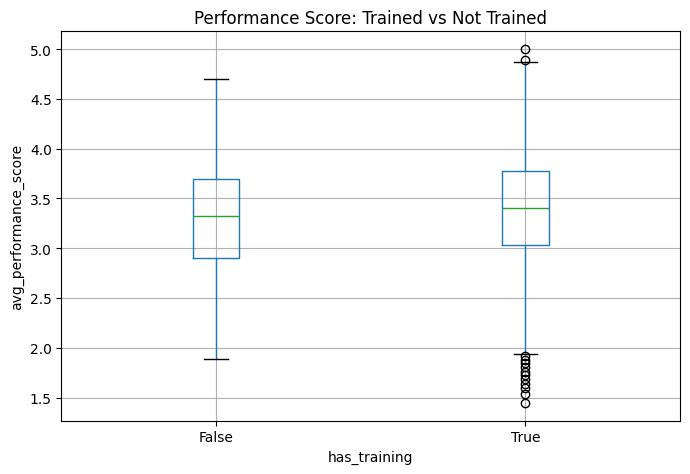

In [12]:
data["has_training"] = data["completed_count"] > 0

print("=" * 70)
print("1) Performance Distribution: Trained vs Not Trained")
print("=" * 70)

perf_by_training = data.groupby("has_training")["avg_performance_score"].agg(
    ["count", "mean", "median", "std"]
)
print(perf_by_training)
print()

fig, ax = plt.subplots(figsize=(7, 5))
data.boxplot(column="avg_performance_score", by="has_training", ax=ax)
ax.set_title("Performance Score: Trained vs Not Trained")
ax.set_xlabel("has_training")
ax.set_ylabel("avg_performance_score")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_1_performance_by_training.png", dpi=120)

2) Average Course Enrollments (total_enrollments) by Job Level
                        count      mean  median
job_level                                      
Individual Contributor   1475  5.387119     5.0
Senior IC                 830  5.768675     6.0
Team Lead                 505  5.990099     6.0
Manager                   359  6.325905     6.0
Senior Manager            215  6.534884     6.0
Director                  116  6.008621     6.0



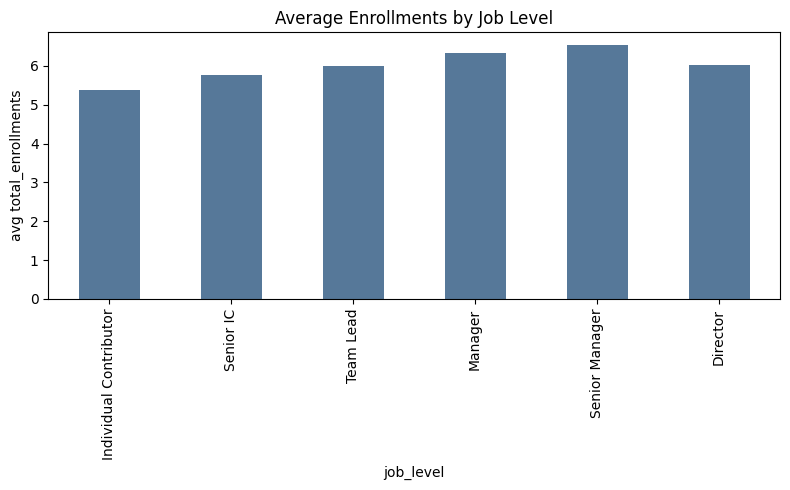

In [ ]:
print("=" * 70)
print("2) Average Course Enrollments (total_enrollments) by Job Level")
print("=" * 70)

level_order = ["Individual Contributor", "Senior IC", "Team Lead",
                "Manager", "Senior Manager", "Director"]
enroll_by_level = (
    data.groupby("job_level")["total_enrollments"]
    .agg(["count", "mean", "median"])
    .reindex(level_order)
)
print(enroll_by_level)
print()

fig, ax = plt.subplots(figsize=(8, 5))
data.groupby("job_level")["total_enrollments"].mean().reindex(level_order).plot(
    kind="bar", ax=ax, color="#567899"
)
ax.set_title("Average Enrollments by Job Level")
ax.set_ylabel("avg total_enrollments")
plt.tight_layout()
plt.savefig("eda_2_enrollments_by_level.png", dpi=120)

In [18]:
print("=" * 70)
print("3) Exit Rate: Trained vs Not Trained")
print("=" * 70)

exit_by_training = data.groupby("has_training")["has_exited"].agg(
    ["count", "sum", "mean"]
).rename(columns={"sum": "exit_count", "mean": "exit_rate"})
exit_by_training["exit_rate_pct"] = (exit_by_training["exit_rate"] * 100).round(2)
print(exit_by_training)

3) Exit Rate: Trained vs Not Trained
              count  exit_count  exit_rate  exit_rate_pct
has_training                                             
False           132          13   0.098485           9.85
True           3368         154   0.045724           4.57


In [20]:
print("=" * 70)
print("4) Promotion Rate (promotion_count > 0) by Training Category")
print("=" * 70)

data["was_promoted"] = data["promotion_count"] > 0
category_cols = [c for c in data.columns if c.startswith("trained_in_")]

promo_by_category = {}
for col in category_cols:
    sub = data.groupby(col)["was_promoted"].mean()
    promo_by_category[col] = {
        "promo_rate_if_trained": round(sub.get(1, float("nan")) * 100, 2),
        "promo_rate_if_not_trained": round(sub.get(0, float("nan")) * 100, 2),
    }
promo_df = pd.DataFrame(promo_by_category).T
promo_df

4) Promotion Rate (promotion_count > 0) by Training Category


,promo_rate_if_trained,promo_rate_if_not_trained
trained_in_compliance,17.12,9.93
trained_in_customer_experience,17.33,16.78
trained_in_leadership,18.91,16.19
trained_in_sales_enablement,19.09,16.59
trained_in_soft_skills,19.70,16.16
trained_in_technical,20.35,15.58


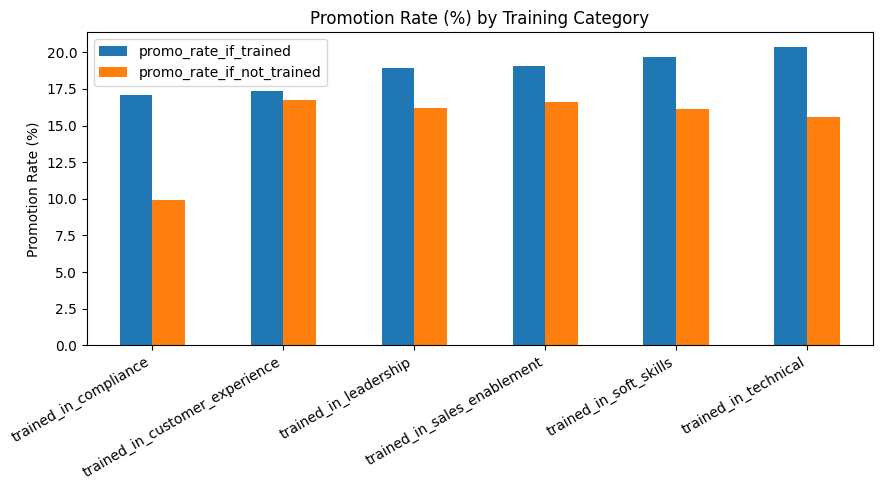

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
promo_df.plot(kind="bar", ax=ax)
ax.set_title("Promotion Rate (%) by Training Category")
ax.set_ylabel("Promotion Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

5) Training Cost Distribution (total_training_cost_usd) by Department
                  count  total_cost  avg_cost_per_person
department                                              
Customer Support    826    619660.0                750.2
Engineering         966    779660.0                807.1
Operations          640    491030.0                767.2
Sales              1068    842095.0                788.5



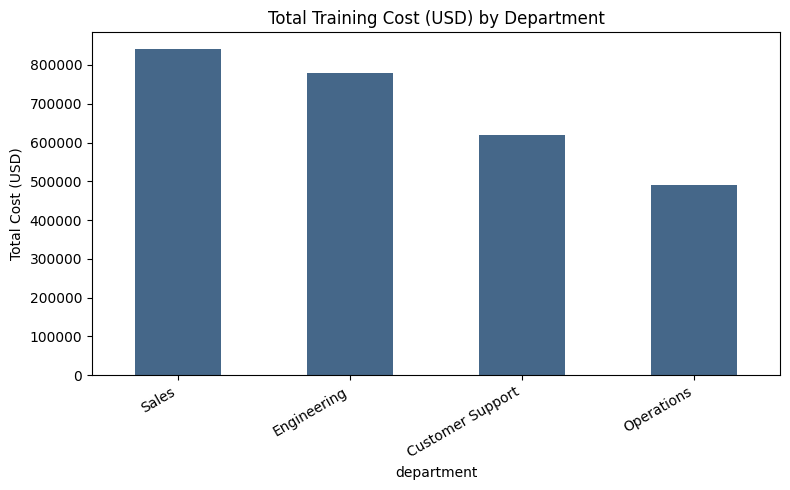

In [24]:
print("=" * 70)
print("5) Training Cost Distribution (total_training_cost_usd) by Department")
print("=" * 70)

cost_by_dept = data.groupby("department")["total_training_cost_usd"].agg(
    ["count", "sum", "mean"]
).rename(columns={"sum": "total_cost", "mean": "avg_cost_per_person"})
cost_by_dept["total_cost"] = cost_by_dept["total_cost"].round(0)
cost_by_dept["avg_cost_per_person"] = cost_by_dept["avg_cost_per_person"].round(1)
print(cost_by_dept)
print()

fig, ax = plt.subplots(figsize=(8, 5))
cost_by_dept["total_cost"].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#456789")
ax.set_title("Total Training Cost (USD) by Department")
ax.set_ylabel("Total Cost (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [27]:
print("=" * 90)
print("1) Performance Comparison: Trained vs Not Trained, within each job_level")
print("=" * 90)

rows = []
for level in level_order:
    sub = data[data["job_level"] == level]
    trained = sub[sub["has_training"]]["avg_performance_score"].dropna()
    not_trained = sub[~sub["has_training"]]["avg_performance_score"].dropna()

    n_trained, n_not_trained = len(trained), len(not_trained)
    if n_trained < 2 or n_not_trained < 2:
        # If either group in this level has fewer than 2 people, statistical testing
        # is meaningless (variance cannot be calculated) - skip it, not fill with fake numbers
        rows.append({
            "job_level": level, "n_trained": n_trained, "n_not_trained": n_not_trained,
            "mean_trained": round(trained.mean(), 3) if n_trained else None,
            "mean_not_trained": round(not_trained.mean(), 3) if n_not_trained else None,
            "diff": None, "p_value": None, "significant_at_0.05": "Insufficient sample",
        })
        continue

    diff = trained.mean() - not_trained.mean()
    t_stat, p_value = stats.ttest_ind(trained, not_trained, equal_var=False)

    rows.append({
        "job_level": level,
        "n_trained": n_trained,
        "n_not_trained": n_not_trained,
        "mean_trained": round(trained.mean(), 3),
        "mean_not_trained": round(not_trained.mean(), 3),
        "diff": round(diff, 3),
        "p_value": round(p_value, 4),
        "significant_at_0.05": "Yes" if p_value < 0.05 else "No",
    })

perf_stratified = pd.DataFrame(rows)
print(perf_stratified.to_string(index=False))
print()
print("Column explanation: diff = mean(Trained) - mean(Not Trained) | "
      "p_value less than 0.05 means the difference is likely not due to chance.\n")

1) Performance Comparison: Trained vs Not Trained, within each job_level
             job_level  n_trained  n_not_trained  mean_trained  mean_not_trained   diff  p_value significant_at_0.05
Individual Contributor       1407             68         3.387             3.226  0.161   0.0147                 Yes
             Senior IC        807             23         3.407             3.419 -0.013   0.9201                  No
             Team Lead        488             17         3.447             3.362  0.086   0.5870                  No
               Manager        346             13         3.377             3.323  0.054   0.7864                  No
        Senior Manager        208              7         3.388             3.266  0.122   0.4532                  No
              Director        112              4         3.406             3.254  0.153   0.5482                  No

Column explanation: diff = mean(Trained) - mean(Not Trained) | p_value less than 0.05 means the difference 

In [28]:
print("=" * 90)
print("2) Exit Rate Comparison: Trained vs Not Trained, within each job_level")
print("=" * 90)

exit_rows = []
for level in level_order:
    sub = data[data["job_level"] == level]
    trained = sub[sub["has_training"]]["has_exited"]
    not_trained = sub[~sub["has_training"]]["has_exited"]

    n_trained, n_not_trained = len(trained), len(not_trained)
    exit_rate_trained = round(trained.mean() * 100, 2) if n_trained else None
    exit_rate_not_trained = round(not_trained.mean() * 100, 2) if n_not_trained else None

    exit_rows.append({
        "job_level": level,
        "n_trained": n_trained,
        "n_not_trained": n_not_trained,
        "exit_rate_trained_pct": exit_rate_trained,
        "exit_rate_not_trained_pct": exit_rate_not_trained,
    })

exit_stratified = pd.DataFrame(exit_rows)
print(exit_stratified.to_string(index=False))
print()

2) Exit Rate Comparison: Trained vs Not Trained, within each job_level
             job_level  n_trained  n_not_trained  exit_rate_trained_pct  exit_rate_not_trained_pct
Individual Contributor       1407             68                   4.05                       7.35
             Senior IC        807             23                   4.71                       8.70
             Team Lead        488             17                   6.15                      17.65
               Manager        346             13                   3.76                      15.38
        Senior Manager        208              7                   5.29                      14.29
              Director        112              4                   4.46                       0.00



In [29]:
print("=" * 90)
print("3) Summary: Direction of training effect at each job level (positive means trained group performed better)")
print("=" * 90)

valid_rows = perf_stratified[perf_stratified["diff"].notna()]
positive_count = (valid_rows["diff"] > 0).sum()
total_valid = len(valid_rows)
print(f"Out of {total_valid} comparable job levels, in {positive_count} levels, the average performance "
      f"of the trained group was higher.")
print(valid_rows[["job_level", "diff", "significant_at_0.05"]].to_string(index=False))

3) Summary: Direction of training effect at each job level (positive means trained group performed better)
Out of 6 comparable job levels, in 5 levels, the average performance of the trained group was higher.
             job_level   diff significant_at_0.05
Individual Contributor  0.161                 Yes
             Senior IC -0.013                  No
             Team Lead  0.086                  No
               Manager  0.054                  No
        Senior Manager  0.122                  No
              Director  0.153                  No
